In [229]:
from google.colab import files
uploaded=files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (1).csv


Data Preprocessing

In [230]:
import pandas as pd
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()



,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [231]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
df.describe(include='all').T

(2640, 12)
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


In [232]:
import numpy as np

CAT_COLS         = ['Region', 'Model', 'Source_Type']
NUM_COLS         = ['Production_Units', 'Battery_Capacity_kWh',
                    'Range_km', 'CO2_Saved_tons', 'Charging_Stations','Year','Month']
Sales    = 'Estimated_Deliveries'
Price   = 'Avg_Price_USD'
outlier_report = {}
for col in NUM_COLS + [Sales, Price]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    n_out = ((df[col] < Q1 - 1.5*IQR) |
             (df[col] > Q3 + 1.5*IQR)).sum()

    outlier_report[col] = n_out
    print(n_out)

12
0
0
45
0
0
0
12
0


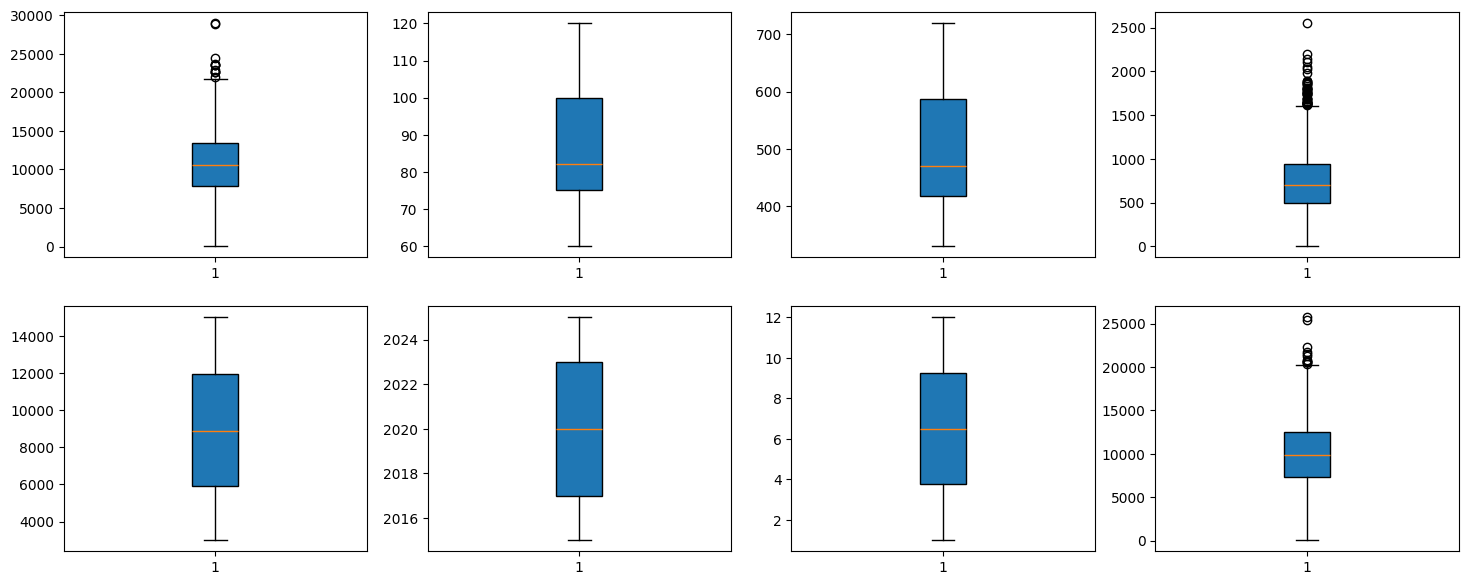

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns
boxplot_columns = NUM_COLS + [Sales, Price]
figure, plot_axes = plt.subplots(2, 4, figsize=(18, 7))
for axis, column in zip(plot_axes.flatten(), boxplot_columns): axis.boxplot(df[column].dropna(), patch_artist=True,)



EDA

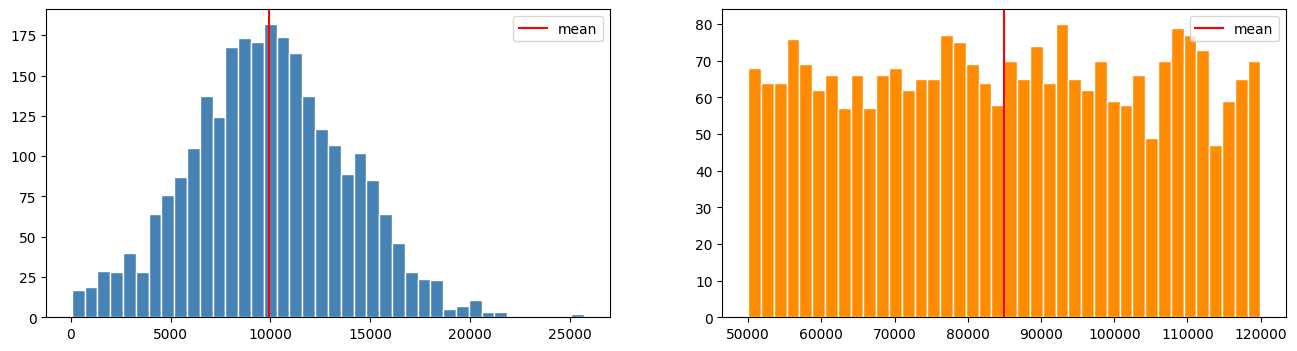

In [234]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(df['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['Estimated_Deliveries'].mean(), color='red', label='mean')
axes[0].legend()
axes[1].hist(df['Avg_Price_USD'], bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(df['Avg_Price_USD'].mean(), color='red',label='mean')
axes[1].legend()
plt.show()

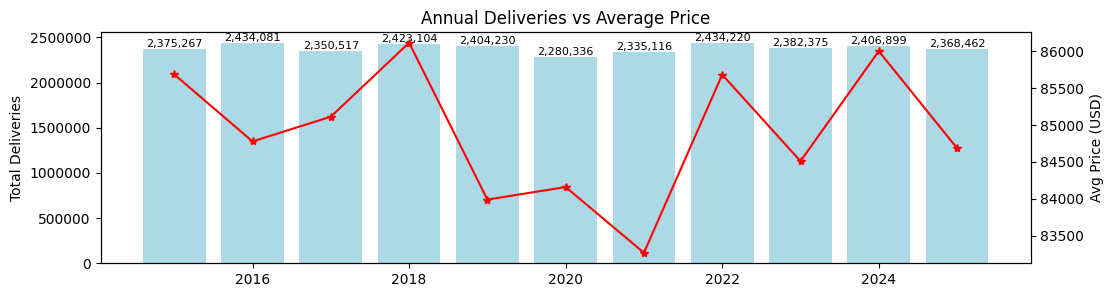

In [235]:
yearly = df.groupby('Year').agg(Total_Deliveries=('Estimated_Deliveries', 'sum'),
 Avg_Price=('Avg_Price_USD', 'mean')).reset_index()
fig, ax1 = plt.subplots(figsize=(12, 3))
ax2 = ax1.twinx()
ax1.bar(yearly['Year'], yearly['Total_Deliveries'], color='lightblue')
bars = ax1.bar(yearly['Year'], yearly['Total_Deliveries'], color='lightblue')
for bar in bars:
    height = bar.get_height()
    ax1.text(  bar.get_x() + bar.get_width()/2,height, f'{height:,.0f}',ha='center', va='bottom',fontsize=8)
ax2.plot(yearly['Year'], yearly['Avg_Price'], color='red', marker='*')
ax1.ticklabel_format(style='plain')
ax1.set_ylabel('Total Deliveries')
ax2.set_ylabel('Avg Price (USD)')
plt.title('Annual Deliveries vs Average Price')
plt.show()

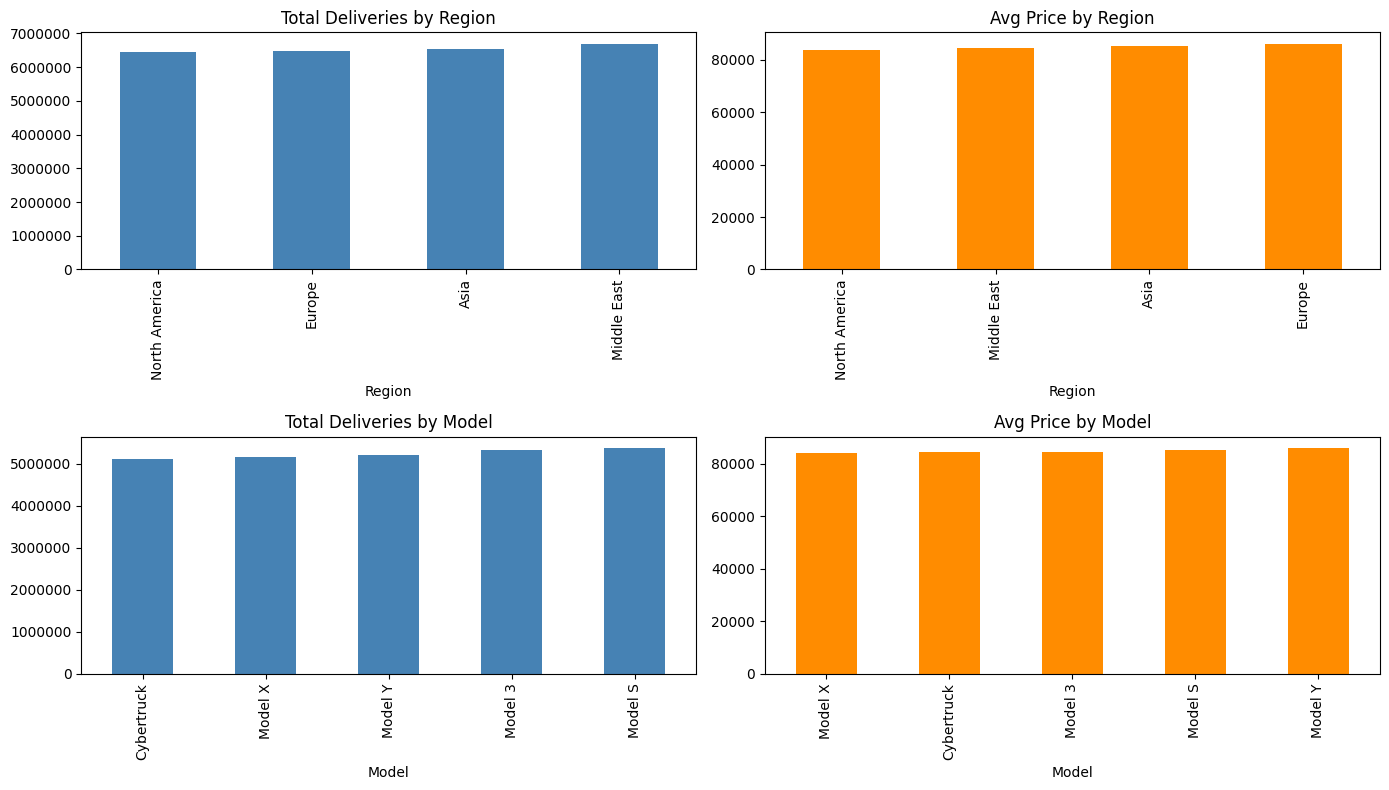

In [236]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

reg = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
reg.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Deliveries by Region')
axes[0,0].ticklabel_format(style='plain', axis='y')

reg1 = df.groupby('Region')['Avg_Price_USD'].mean().sort_values()
reg1.plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Avg Price by Region')

mod = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()
mod.plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Total Deliveries by Model')
axes[1,0].ticklabel_format(style='plain', axis='y')


mod_p = df.groupby('Model')['Avg_Price_USD'].mean().sort_values()
mod_p.plot(kind='bar', ax=axes[1,1], color='darkorange')
axes[1,1].set_title('Avg Price by Model')
plt.tight_layout()
plt.show()

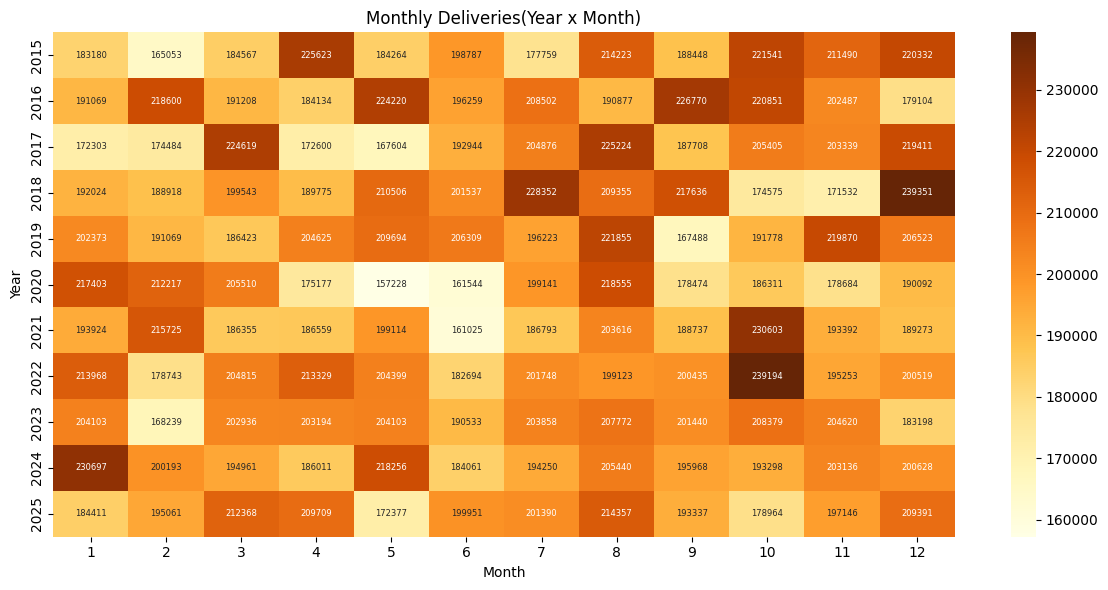

In [237]:
pivot = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().unstack('Month')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlOrBr', annot=True, annot_kws={'size': 6}, fmt='.0f')
plt.title('Monthly Deliveries(Year x Month)')
plt.tight_layout()
plt.show()

Feature Engineering

In [238]:
df2=df.copy()
df2 ['Quarter'] = ((df2['Month']+2) // 3)
df2['Delivery_Rate']  = df2['Estimated_Deliveries'] / (df2['Production_Units'].replace(0, np.nan))
df2['Revenue_Est']    = df2['Estimated_Deliveries'] * df2['Avg_Price_USD']
df2['Revenue_Est_Display'] = df2['Revenue_Est'].map('${:,.2f}'.format)
df2

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Delivery_Rate,Revenue_Est,Revenue_Est_Display
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2,0.984600,1.638859e+09,"$1,638,859,368.42"
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,1,0.911864,2.361949e+08,"$236,194,853.05"
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,1,0.915334,9.915502e+08,"$991,550,248.52"
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,1,0.896594,5.853281e+08,"$585,328,135.05"
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,4,0.914087,1.421114e+09,"$1,421,114,055.72"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273,4,0.941045,1.534545e+09,"$1,534,544,596.80"
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833,3,0.994187,1.498581e+09,"$1,498,580,961.00"
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709,3,0.895680,1.291079e+09,"$1,291,079,499.58"
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754,2,0.934572,2.429373e+08,"$242,937,268.47"


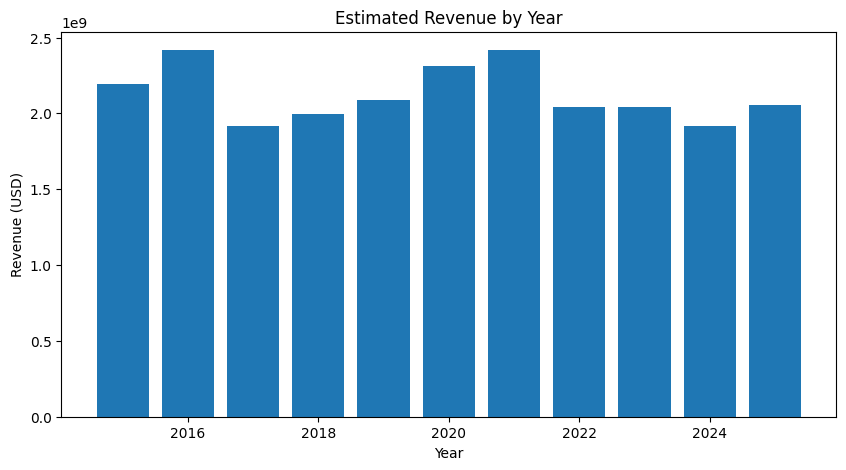

In [239]:
plt.figure(figsize=(10,5))
plt.bar(df2['Year'],df2['Revenue_Est'])
plt.title('Estimated Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.show()

Regression model

In [240]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X = df2.drop(columns=['Estimated_Deliveries'])
y = df2['Estimated_Deliveries']
X = X.drop(columns=['Revenue_Est'], errors='ignore')
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    sales_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, sales_pred),
        'MSE': mean_squared_error(y_test, sales_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, sales_pred)),
        'R²': r2_score(y_test, sales_pred)
    })
results = pd.DataFrame(results)
results



,Model,MAE,MSE,RMSE,R²
0,Linear Regression,130.834243,32989.520963,181.630176,0.997706
1,Ridge Regression,162.488208,46879.863627,216.517583,0.996740
2,Lasso Regression,103.495398,22807.874289,151.022761,0.998414


MODEL EVALUATION

In [241]:
prediction = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': sales_pred
})
prediction.head(10)


,Actual Sales,Predicted Sales
0,16123,15790.870749
1,11286,11382.788252
2,13550,13706.473254
3,11824,11861.444029
4,7500,7461.227661
5,13516,13694.648204
6,10719,10691.827978
7,18301,18166.145776
8,10488,10454.089894
9,6192,6384.667808


hyperparameter tuning

In [242]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
params = { 'alpha': [0.01, 0.1, 1, 10, 100]}
grid_ridge = GridSearchCV( ridge, param_grid=params, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)
print("Best Parameters:", grid_ridge.best_params_)
print("Best R2 Score:", grid_ridge.best_score_)

Best Parameters: {'alpha': 0.01}
Best R2 Score: 0.9975133856536427


In [243]:
from sklearn.model_selection import GridSearchCV

lasso = Lasso(max_iter=5000)

params = { 'alpha': [0.001, 0.01, 0.1, 1, 10]}

grid_lasso = GridSearchCV(lasso,param_grid=params,cv=5, scoring='r2')
grid_lasso.fit(X_train, y_train)
print("Best Parameters:", grid_lasso.best_params_)
print("Best R2 Score:", grid_lasso.best_score_)

Best Parameters: {'alpha': 0.01}
Best R2 Score: 0.9984069343784144


Time series forecasting for the year 2026 and 2027

In [249]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
ts = df2.copy()
ts['Date'] = pd.to_datetime(ts['Year'].astype(str) + '-' +ts['Month'].astype(str) + '-01')
ts = ts.sort_values('Date')
sales_ts = ts.groupby('Date')['Estimated_Deliveries'].sum()
model = ARIMA(sales_ts, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=24)
forecast_df = forecast.reset_index()
forecast_df.columns = ['Date', 'Forecasted_Deliveries']
forecast_df

,Date,Forecasted_Deliveries
0,2026-01-01,201130.711312
1,2026-02-01,199815.368230
2,2026-03-01,199605.917024
3,2026-04-01,199572.564655
4,2026-05-01,199567.253726
5,2026-06-01,199566.408030
6,2026-07-01,199566.273364
7,2026-08-01,199566.251920
8,2026-09-01,199566.248506
9,2026-10-01,199566.247962
